# 03. Documento de trabajo para verificar la hipótesis #02

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

clean_data_df = pd.read_csv("..\\data\\CLEAN_Students_Social_Media_Addiction.csv")
clean_data_df.index = clean_data_df["Student_ID"]

clean_data_df = clean_data_df.drop(columns=["Unnamed: 0"]) # Eliminamos la columna que había quedado guardada como índice
clean_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 503 entries, 3 to 705
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    503 non-null    int64  
 1   Age                           503 non-null    int64  
 2   Gender                        503 non-null    object 
 3   Academic_Level                503 non-null    object 
 4   Country                       503 non-null    object 
 5   Avg_Daily_Usage_Hours         503 non-null    float64
 6   Most_Used_Platform            503 non-null    object 
 7   Affects_Academic_Performance  503 non-null    object 
 8   Sleep_Hours_Per_Night         503 non-null    float64
 9   Mental_Health_Score           503 non-null    int64  
 10  Relationship_Status           503 non-null    object 
 11  Conflicts_Over_Social_Media   503 non-null    int64  
 12  Addicted_Score                503 non-null    int64  
dtypes: float64

### 3.2 Hipótesis: Los usuarios que mayoritariamente usan Instagram y Tik Tok, puntuan como más adictos en la **Bergen Social Media Addiction Scale**  que aquellos encuestados con preferencia por otras redes sociales

In [2]:
mean_bergen_addiction_scale_grouped_by_most_used_platform = clean_data_df.groupby("Most_Used_Platform")['Addicted_Score'].mean().reset_index()
mean_bergen_addiction_scale_grouped_by_most_used_platform.columns = ["Most_Used_Platform", "Avg_Addicted_Score"]
mean_bergen_addiction_scale_grouped_by_most_used_platform = mean_bergen_addiction_scale_grouped_by_most_used_platform.sort_values(by="Avg_Addicted_Score", ascending=False)
mean_bergen_addiction_scale_grouped_by_most_used_platform

,Most_Used_Platform,Avg_Addicted_Score
3,Snapchat,7.461538
4,TikTok,7.398438
1,Instagram,6.321782
6,YouTube,6.250000
5,Twitter,5.586207
0,Facebook,5.470588
2,LinkedIn,3.809524


In [3]:
# Respecto al mayor dato de "Avg_Addicted_Score", vamos a revisar qué porcentaje de dicho valor representan el resto de filas:

top_addiction_baseline = mean_bergen_addiction_scale_grouped_by_most_used_platform.iloc[[0]]["Avg_Addicted_Score"].item()

mean_bergen_addiction_scale_grouped_by_most_used_platform["Relative_to_TOP_addicted_score_%"] = (mean_bergen_addiction_scale_grouped_by_most_used_platform["Avg_Addicted_Score"] / top_addiction_baseline) * 100
mean_bergen_addiction_scale_grouped_by_most_used_platform

,Most_Used_Platform,Avg_Addicted_Score,Relative_to_TOP_addicted_score_%
3,Snapchat,7.461538,100.000000
4,TikTok,7.398438,99.154317
1,Instagram,6.321782,84.724916
6,YouTube,6.250000,83.762887
5,Twitter,5.586207,74.866690
0,Facebook,5.470588,73.317162
2,LinkedIn,3.809524,51.055474


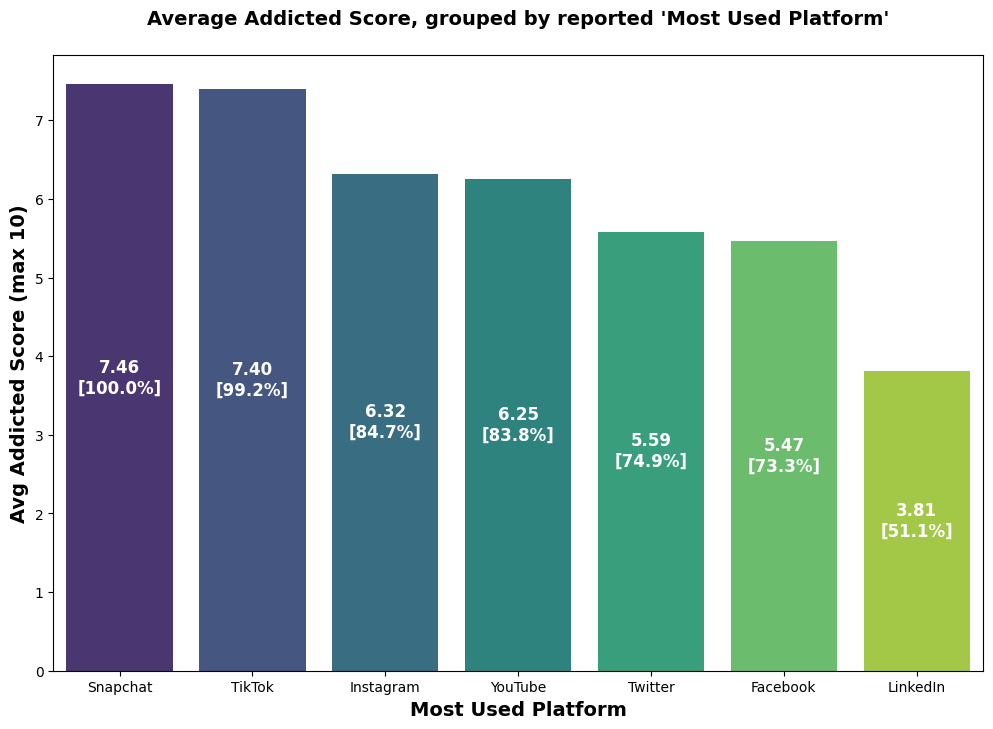

In [5]:
# Extraemos el gráfico a mostrar

plt.figure(figsize=(12, 8))

fig = sns.barplot(
    data=mean_bergen_addiction_scale_grouped_by_most_used_platform, 
    hue=mean_bergen_addiction_scale_grouped_by_most_used_platform["Most_Used_Platform"],
    x=mean_bergen_addiction_scale_grouped_by_most_used_platform["Most_Used_Platform"],
    y=mean_bergen_addiction_scale_grouped_by_most_used_platform["Avg_Addicted_Score"],
    palette="viridis")

for p in fig.patches:
    # Get the height of the bar (the value on the y-axis)
    height = p.get_height()

    x_category = fig.get_xticklabels()[fig.patches.index(p)].get_text() # Encuentra la Label del eje X, para poder buscar el porcentaje en el Dataframe

    # 2d. Lookup the specific Label_Text from the DataFrame
    label_percentage = mean_bergen_addiction_scale_grouped_by_most_used_platform[mean_bergen_addiction_scale_grouped_by_most_used_platform['Most_Used_Platform'] == x_category]['Relative_to_TOP_addicted_score_%'].iloc[0]
    final_label = f'{height:.2f}' + "\n" + f'[{label_percentage:.1f}%]' # Format the text (e.g., to 2 decimal places)
    # Determine where to place the label:
    # x-coordinate: p.get_x() + p.get_width() / 2 (Center of the bar)
    # y-coordinate: height / 2 (Halfway up the bar, inside)

    # Add the text annotation
    fig.text(
        x=p.get_x() + p.get_width() / 2.,  # Center horizontally
        y=height * 0.5,                   # Place vertically at 50% height
        s=final_label,                     # The text to display
        ha='center',                      # Horizontal alignment
        va='center',                      # Vertical alignment
        color='white',                    # Use a contrasting color
        fontsize=12,
        fontweight='bold'
    )

fig.set_title("Average Addicted Score, grouped by reported 'Most Used Platform'" + "\n", fontweight='bold', fontsize=14);
fig.set_xlabel("Most Used Platform", fontweight='bold', fontsize=14);
fig.set_ylabel("Avg Addicted Score (max 10)", fontweight='bold', fontsize=14)
#plt.ylim(0, 10) # Se ve mejor sin el limite superior en 10
plt.show();

#### 🤷‍♂️ Tan sólo podemos validar parcialmente la hipótesis 2 

Esperábamos ver Tik Tok e Instagram en el Top 2 de redes que podríamos vincular con un mayor índice de adicción, sin embargo, tan sólo vemos a Tik Tok en este Top 2, siendo Snapchat la que nos ha sorprendido como aquella donde observamos el mayor índice de adicción